**NOTA:**

Artur:

1.análise do conjunto de dados e sua breve descrição  ✅

5.análise preditiva/ aprendizagem de máquina (classificação ou regressão conforme apropriado), comparando o desempenho de vários modelos

Maria:

2.tarefas de pré-processamento dos dados (se julgar necessárias) ✅

6.seleção/ importância das variáveis usadas pelos modelos

Catarina:

3.sumarização dos dados (estatística descritiva, exploração com recurso a gráficos) ✅

4.análise estatística multivariada (não supervisionada): clustering, redução de dimensionalidade/ visualização ✅

# **Practical Assignment 2 – Python Application**

# 1. Analysis of the dataset and its brief description

## 1.1 Introduction
The goal of this practical assignment is to apply data analysis and knowledge extraction techniques to biological data, with a focus on predicting the mutagenicity of chemical compounds. The task involves developing a complete pipeline in Python, including data loading, preprocessing, exploratory analysis, predictive modeling, and performance evaluation.

The dataset used corresponds to the Ames test, a widely adopted biological assay for identifying compounds with mutagenic potential. It includes a matrix of numerical molecular descriptors (features) and a binary label indicating whether each compound is **mutagenic** `(1)` or **not** `(0)`.

This work provides an opportunity to apply several concepts covered throughout the semester, including multivariate analysis, supervised learning, feature selection, and data visualization.

## **Imports**

In [60]:
import pandas as pd
import numpy as np
import pprint
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mstats
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram

## 1.2 Assigment Context - Ames Mutagenicity

### Dataset Description: 

Mutagenicity means the ability of a drug to induce genetic alterations. Drugs that can cause damage to the DNA can result in cell death or other severe adverse effects. Nowadays, the most widely used assay for testing the mutagenicity of compounds is the Ames experiment which was invented by a professor named Ames. The Ames test is a short-term bacterial reverse mutation assay detecting a large number of compounds which can induce genetic damage and frameshift mutations. The dataset is aggregated from four papers.

### Task Description: 

Binary classification. Given a drug SMILES string, predict whether it is mutagenic `(1)` or not mutagenic `(0)`.

## 1.3 Data Exploration with Python

In [61]:
# Load the features dataset
features_path = "data_csv/ames_features.csv"
X = pd.read_csv(features_path)

# Basic dataset information
features_info = {
    "Shape": X.shape,
    "Columns": X.columns.tolist(),
    "Missing Values": X.isnull().sum().sum(),
    "Preview": X.head()
}

print("Dataset Shape:")
pprint.pprint(features_info["Shape"])

Dataset Shape:
(7273, 208)


In [62]:
print("\n Feature Columns (truncated list):")
pprint.pprint(features_info["Columns"])


 Feature Columns (truncated list):
['MaxEStateIndex',
 'MinEStateIndex',
 'MaxAbsEStateIndex',
 'MinAbsEStateIndex',
 'qed',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'NumValenceElectrons',
 'NumRadicalElectrons',
 'MaxPartialCharge',
 'MinPartialCharge',
 'MaxAbsPartialCharge',
 'MinAbsPartialCharge',
 'FpDensityMorgan1',
 'FpDensityMorgan2',
 'FpDensityMorgan3',
 'BCUT2D_MWHI',
 'BCUT2D_MWLOW',
 'BCUT2D_CHGHI',
 'BCUT2D_CHGLO',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'BCUT2D_MRHI',
 'BCUT2D_MRLOW',
 'BalabanJ',
 'BertzCT',
 'Chi0',
 'Chi0n',
 'Chi0v',
 'Chi1',
 'Chi1n',
 'Chi1v',
 'Chi2n',
 'Chi2v',
 'Chi3n',
 'Chi3v',
 'Chi4n',
 'Chi4v',
 'HallKierAlpha',
 'Ipc',
 'Kappa1',
 'Kappa2',
 'Kappa3',
 'LabuteASA',
 'PEOE_VSA1',
 'PEOE_VSA10',
 'PEOE_VSA11',
 'PEOE_VSA12',
 'PEOE_VSA13',
 'PEOE_VSA14',
 'PEOE_VSA2',
 'PEOE_VSA3',
 'PEOE_VSA4',
 'PEOE_VSA5',
 'PEOE_VSA6',
 'PEOE_VSA7',
 'PEOE_VSA8',
 'PEOE_VSA9',
 'SMR_VSA1',
 'SMR_VSA10',
 'SMR_VSA2',
 'SMR_VSA3',
 'SMR_VSA4',
 'SMR_VSA

In [63]:
print("Total Missing Values:")
print(features_info["Missing Values"])

Total Missing Values:
0


In [64]:
print("Dataset Preview (first 5 rows):")
features_info["Preview"]

Dataset Preview (first 5 rows):


,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,11.663401,-0.396099,11.663401,0.008895,0.181963,342.310,332.230,342.06406,124.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,11.824743,-0.170602,11.824743,0.170602,0.269289,301.345,286.225,301.11030,112.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,14.431072,-0.378575,14.431072,0.128988,0.184582,646.614,628.470,646.11650,232.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,10.422196,-0.670278,10.422196,0.248657,0.103849,157.133,150.077,157.05997,60.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,10.521759,-0.752407,10.521759,0.278148,0.342148,138.086,136.070,138.01778,50.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### **Output**

In [65]:
# Load the features dataset
features_path = "data_csv/ames_outputs.csv"
features_df = pd.read_csv(features_path)

# Basic dataset information
features_info = {
    "Shape": features_df.shape,
    "Columns": features_df.columns.tolist(),
    "Missing Values": features_df.isnull().sum().sum(),
    "Preview": features_df.head(),
    "Class Distribution": features_df['Y'].value_counts().to_dict()
}

print("Dataset Shape:")
pprint.pprint(features_info["Shape"])

Dataset Shape:
(7273, 3)


In [66]:
print("Feature Columns (truncated list):")
pprint.pprint(features_info["Columns"])

Feature Columns (truncated list):
['ids', 'smiles', 'Y']


In [67]:
print("Total Missing Values:")
print(features_info["Missing Values"])

Total Missing Values:
0


In [68]:
print("Dataset Preview (first 5 rows):")
features_info["Preview"]

Dataset Preview (first 5 rows):


,ids,smiles,Y
0,Drug 0,O=[N+]([O-])c1ccc2ccc3ccc([N+](=O)[O-])c4c5ccc...,1
1,Drug 1,O=[N+]([O-])c1c2c(c3ccc4cccc5ccc1c3c45)CCCC2,1
2,Drug 2,O=c1c2ccccc2c(=O)c2c1ccc1c2[nH]c2c3c(=O)c4cccc...,0
3,Drug 3,[N-]=[N+]=CC(=O)NCC(=O)NN,1
4,Drug 4,[N-]=[N+]=C1C=NC(=O)NC1=O,1


In [69]:
print("Class Distribution — 1 = mutagenic, 0 = non-mutagenic:")
pprint.pprint(features_info["Class Distribution"])

Class Distribution — 1 = mutagenic, 0 = non-mutagenic:
{0: 3299, 1: 3974}


## 1.4 Datasets Overview

This project utilizes two datasets derived from the Ames mutagenicity test: one containing molecular features extracted from chemical structures, and another providing binary mutagenicity classification labels.

---

### Dataset Features

This dataset includes computed molecular descriptors and fragment-based features for each compound, derived from its SMILES (Simplified Molecular Input Line Entry System) representation.

- **Rows (samples)**: 7,273 compounds  
- **Columns (features)**: 208 numerical descriptors  
- **Types of features**:
  - *Physicochemical*: `MolWt`, `TPSA`, `LogP`, `qed`, etc.
  - *Topological and electronic*: `Chi`, `BalabanJ`, `EState`, etc.
  - *Structural fragments (binary flags)*: `fr_nitro`, `fr_urea`, `fr_halogen`, etc.

The dataset contains no missing values and is ready for use in machine learning tasks.

---

### Dataset Output

This dataset contains binary classification labels indicating the mutagenicity of each compound, aligned with the compounds in the feature dataset.

- **Rows**: 7,273 (one per compound)
- **Columns**:
  - `ids`: Unique compound identifier
  - `smiles`: SMILES representation of the compound
  - `Y`: Binary label for mutagenicity  
    - `1` = Mutagenic  
    - `0` = Non-mutagenic

#### Class Distribution

| Label             | Count |
|-------------------|--------|
| Mutagenic (1)     | 3,974  |
| Non-mutagenic (0) | 3,299  |

There are no missing values in the output dataset. The class distribution is slightly imbalanced, with more mutagenic than non-mutagenic samples.

---

Together, these datasets form a complete and clean structure for building supervised learning models to predict the mutagenic potential of chemical compounds.


# 2. Data preprocessing tasks

Before fitting any predictive model, we apply a systematic sequence of preprocessing steps to the feature dataset. These steps ensure that the data are clean, consistent, and appropriately scaled for machine learning algorithms.

No missing values were detected in the feature dataset. Therefore, no imputation or NA-specific preprocessing was required.  

In this section, we cover the following stages:

**1. Outlier Handling**

Reduce the influence of rare, extreme measurements.

**2. Low-Variance Feature Filtering**

Drop near-constant descriptors that carry little predictive information.

## 2.1 Outlier Handling - Univariate Outlier Detection Across All Features

To identify how many values lie outside the 1st and 99th percentiles for each descriptor, we:

1. **Compute the percentile thresholds**  
   - `q_low` stores the 1st percentile of every column  
   - `q_high` stores the 99th percentile of every column

2. **Count outliers per feature**  
   - We flag values below `q_low` or above `q_high` in each column  
   - Summarize both the raw counts and percentages of outliers

In [70]:
# Compute per-column percentiles
q_low  = X.quantile(0.01)
q_high = X.quantile(0.99)

# Count outliers per column
outlier_counts = ((X < q_low) | (X > q_high)).sum()
outlier_pct    = outlier_counts / len(X) * 100

print("Outliers per feature (count, %):")
print(pd.DataFrame({
    'count': outlier_counts,
    'percent': outlier_pct.round(2)
}))


Outliers per feature (count, %):
                   count  percent
MaxEStateIndex       146     2.01
MinEStateIndex       146     2.01
MaxAbsEStateIndex    146     2.01
MinAbsEStateIndex    144     1.98
qed                  146     2.01
...                  ...      ...
fr_thiazole            4     0.05
fr_thiocyan            3     0.04
fr_thiophene          58     0.80
fr_unbrch_alkane      65     0.89
fr_urea                6     0.08

[208 rows x 2 columns]


Capping these extreme tails helps stabilize models that are sensitive to range and variance, while retaining all samples.

*Why Winsorization?*
- Winsorization limits extreme values by “clamping” them at specified percentile cut-offs rather than dropping rows.
- For each column, values below the lower percentile are set to that percentile value, and values above the upper percentile are set to the upper bound.

`(0.01, 0.01)`

We measured the 1st and 99th percentiles for each feature and found about 1–2 % of observations lie outside those bounds.
Using limits=(0.01, 0.01) directly matches that analysis, ensuring we only clamp the most extreme ~1 % on each tail.

By integrating this `Winsorizer(limits=(0.01, 0.01))` at the start of our preprocessing pipeline, we ensure each descriptor’s most extreme values are tamed in a principled, reproducible way—providing robust inputs for subsequent power-transformation, scaling, and modeling.

In [71]:
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.01, 0.01)):
        self.limits = limits
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_arr = np.asarray(X, dtype=float)
        return np.apply_along_axis(lambda col: mstats.winsorize(col, limits=self.limits), 0, X_arr)

## 2.2 Low-Variance Feauture Filtering

The `VarianceThreshold` transformer removes any feature whose variance does not exceed the specified threshold. Features with very low variance (i.e., nearly constant across samples) carry little to no predictive information and can be safely dropped.

In [72]:
var_filt = VarianceThreshold(threshold=0.01)
var_filt

VarianceThreshold(threshold=0.01)

# 3. Data Summarization

In [73]:
# Apply winsorization to the variance-filtered data
winsor = Winsorizer(limits=(0.01, 0.01))
X_winsor = winsor.fit_transform(X)

# Reconstruct the DataFrame with same column names
X_winsor_df = pd.DataFrame(X_winsor, columns=X.columns)
X_winsor_df['Mutagenic'] = features_df['Y'].values

# Use this updated DataFrame for all of Point 3
df = X_winsor_df

## 3.1 Summary statistics

In [74]:
print("Descriptive Statistics:")
display(df.describe())

Descriptive Statistics:


,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,Mutagenic
count,7273.000000,7273.000000,7273.000000,7273.000000,7273.000000,7273.000000,7273.000000,7273.000000,7273.000000,7273.0,...,7273.000000,7273.0,7273.0,7273.0,7273.000000,7273.0,7273.0,7273.000000,7273.000000,7273.000000
mean,9.356021,-0.449194,9.356021,0.340727,0.510291,241.969826,228.382367,241.606120,87.885192,0.0,...,0.010587,0.0,0.0,0.0,0.011687,0.0,0.0,0.224942,0.017049,0.546405
std,3.014129,1.205136,3.014129,0.346898,0.165930,104.710018,99.332807,104.552023,38.672038,0.0,...,0.102355,0.0,0.0,0.0,0.107481,0.0,0.0,1.083428,0.129464,0.497876
min,2.231806,-4.658179,2.231806,0.003087,0.124224,70.091000,62.051000,69.937706,24.000000,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000
25%,6.209384,-0.846972,6.209384,0.075424,0.396894,165.148000,156.100000,165.039000,60.000000,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000
50%,10.384028,-0.355799,10.384028,0.211296,0.510491,230.270000,218.173000,230.069140,84.000000,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,1.000000
75%,11.488809,0.353001,11.488809,0.510718,0.621552,296.319000,280.241000,296.060400,108.000000,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,1.000000
max,13.697634,1.333333,13.697634,1.430556,0.870769,620.735000,580.426000,620.118160,230.000000,0.0,...,1.000000,0.0,0.0,0.0,1.000000,0.0,0.0,8.000000,1.000000,1.000000


> The dataset contains 7,273 compounds and 208 numerical molecular descriptors. After pre-processing, all features are complete and show consistent ranges. Core descriptors such as `MolWt`, `qed`, and `NumValenceElectrons` present substantial variability, while fragment-based features remain sparse and mostly binary. The data is well-structured for further analysis.


## 3.2 Target variable distribution

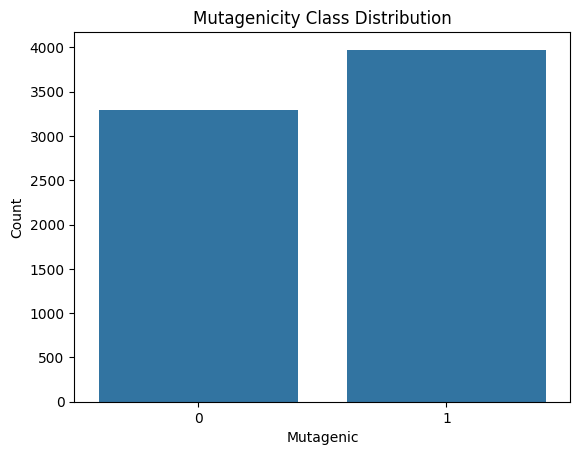

In [75]:
sns.countplot(x='Mutagenic', data=df)
plt.title("Mutagenicity Class Distribution")
plt.xlabel("Mutagenic")
plt.ylabel("Count")
plt.show()

> The `Mutagenic` target variable has slightly more positive (mutagenic) samples than negative ones. This distribution is suitable for classification tasks without requiring strong resampling techniques. The class proportions are close enough to avoid major bias during model training.


## 3.3 Feature distributions by variance

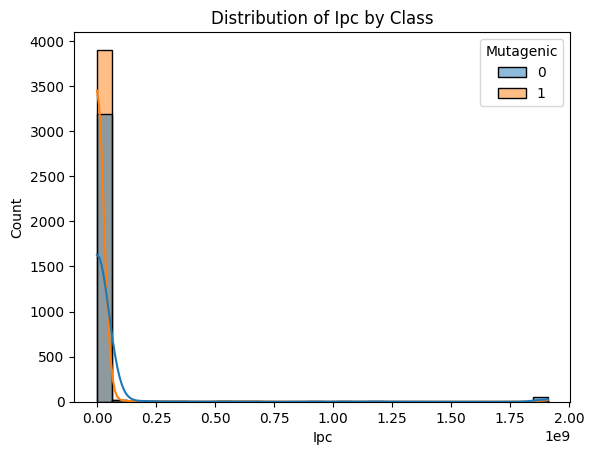

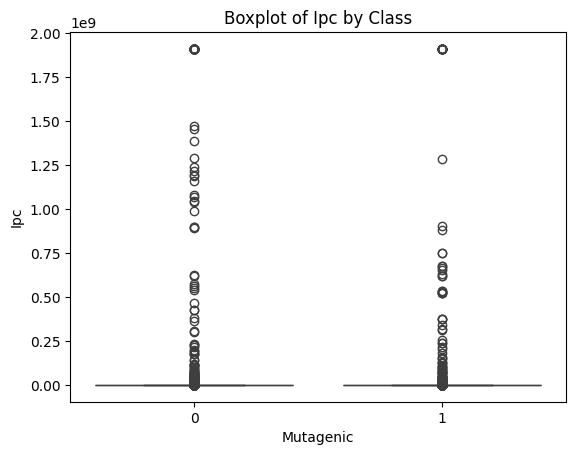

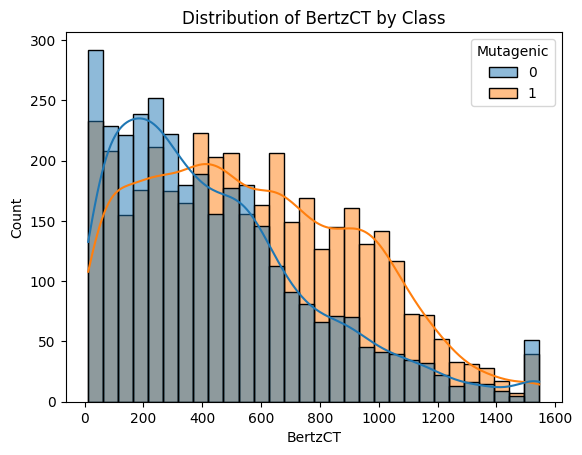

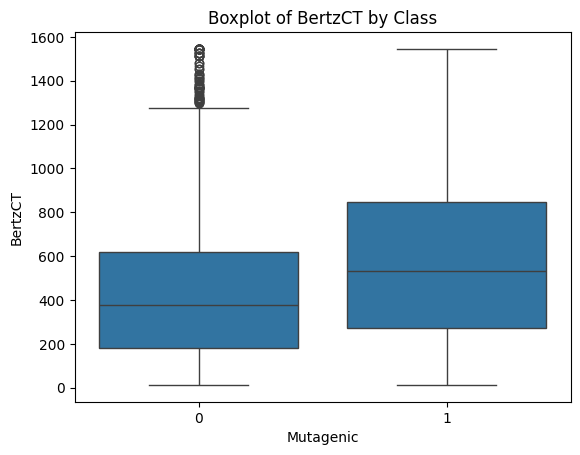

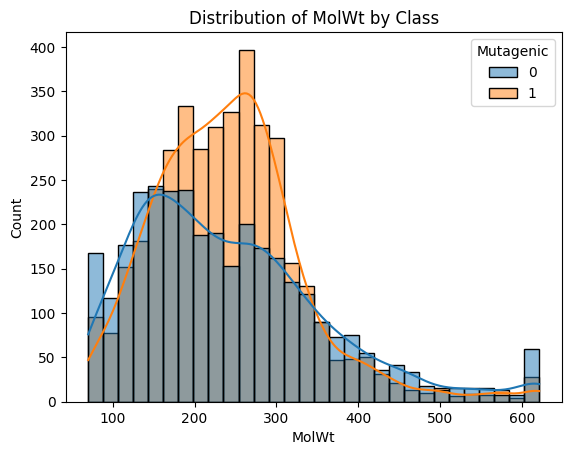

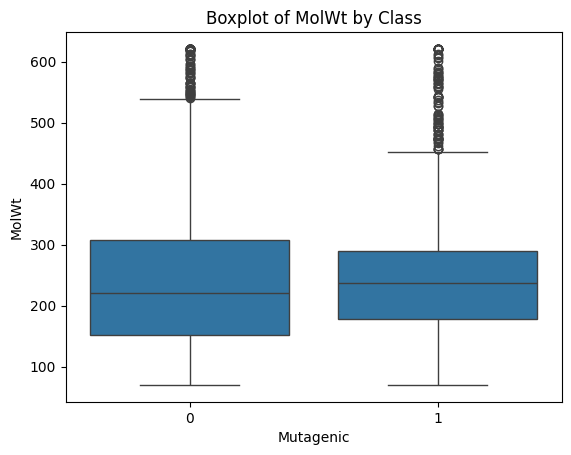

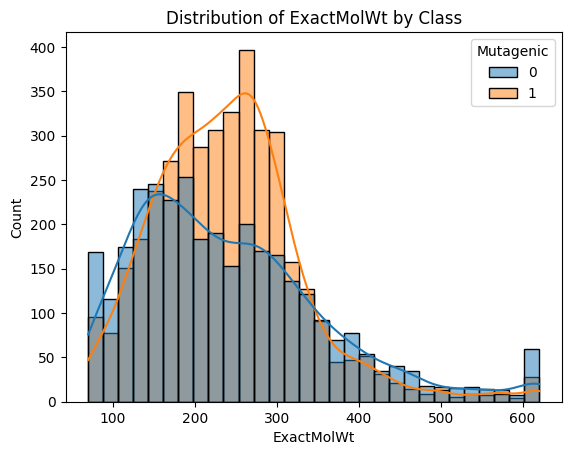

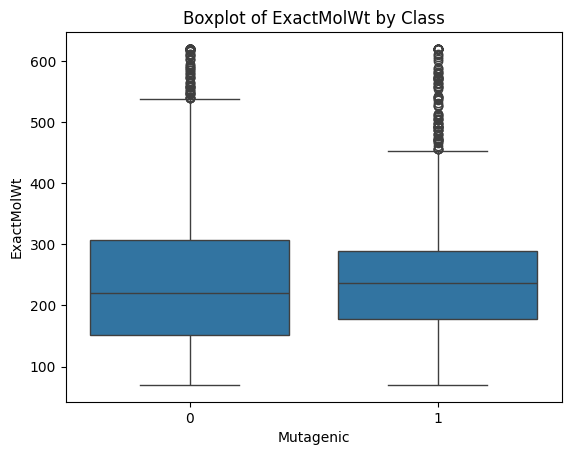

In [76]:
variances = df.drop(columns='Mutagenic').var()
top_features = variances.sort_values(ascending=False).head(4).index

# Visual inspection of key features
for feat in top_features:
    sns.histplot(data=df, x=feat, hue='Mutagenic', kde=True, bins=30)
    plt.title(f"Distribution of {feat} by Class")
    plt.show()

    sns.boxplot(x='Mutagenic', y=feat, data=df)
    plt.title(f"Boxplot of {feat} by Class")
    plt.show()

> Several molecular descriptors show different distribution patterns between mutagenic and non-mutagenic compounds:
>
>* **Ipc** is extremely right-skewed for both classes, with most values concentrated near zero and a few very large outliers. The boxplot confirms this with long upper whiskers and numerous extreme values, even after winsorization.
>* **BertzCT** displays a visible shift in distribution: mutagenic compounds tend to have higher complexity scores, with the median and upper quartile notably higher than in the non-mutagenic group.
>* **MolWt** and **ExactMolWt** also tend to be slightly higher for mutagenic compounds, though the overlap is substantial. Both descriptors show moderate right-skew and many outliers above \~500 Da.
>
>These patterns suggest that higher molecular weight and structural complexity may be associated with mutagenicity, while some descriptors (e.g., Ipc) may be dominated by a small number of extreme values.


## 3.4 Correlation matrix heatmap

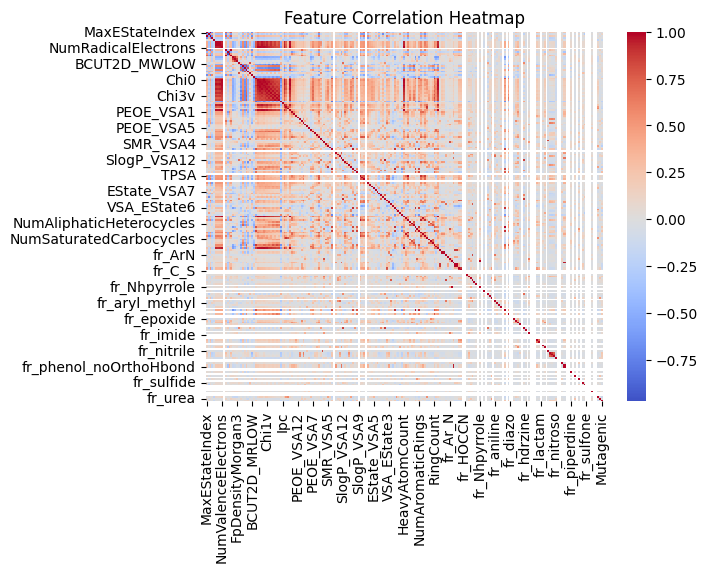

In [77]:
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

>The correlation heatmap reveals several strong linear relationships among descriptors. In particular:
>
>* **Highly correlated groups** are visible among related descriptors, such as EState and VSA variants, which often capture overlapping structural properties.
>* **Fragment-based features** (e.g., `fr_aromatic`, `fr_nitro`) show weak to moderate correlation with other features and with `Mutagenic`, suggesting they may carry complementary signal.
>* The variable `Mutagenic` appears only weakly correlated with most individual features, indicating that mutagenicity likely depends on **nonlinear combinations** of descriptors — supporting the use of machine learning for classification.
>
>This structure reinforces the importance of dimensionality reduction and multivariate models for downstream analysis.


# 4. Multivariate statistical analysis (unsupervised)

## 4.1 Normalize features

In [84]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_winsor)

## 4.2 PCA projection

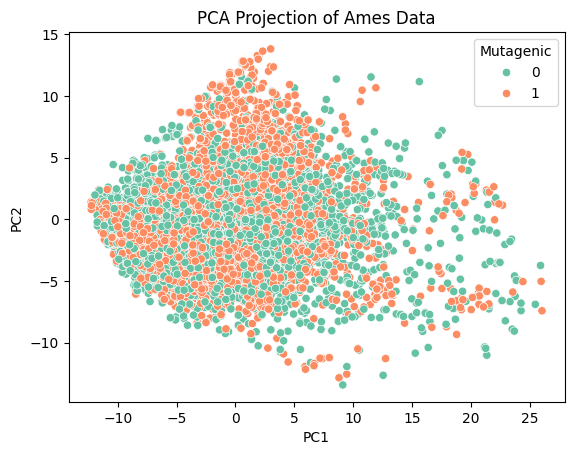

In [85]:
pca = PCA(n_components=2)
pca_proj = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(pca_proj, columns=['PC1', 'PC2'])
pca_df['Mutagenic'] = y.values

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Mutagenic', palette='Set2')
plt.title("PCA Projection of Ames Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

>The PCA projection onto the first two components shows that mutagenic and non-mutagenic compounds partially overlap, with no clear linear separation. However, subtle clustering tendencies and structural gradients are visible, suggesting that mutagenicity may be influenced by complex, multivariate interactions across descriptors. PCA successfully reduces dimensionality while retaining variation, providing a solid base for further unsupervised exploration.



## 4.3 t-SNE projection

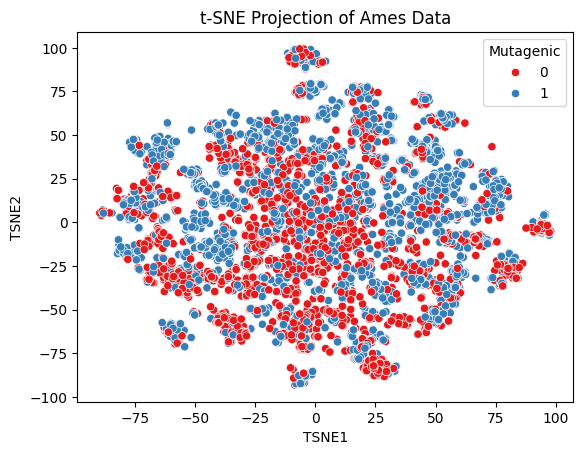

In [86]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_proj = tsne.fit_transform(X_scaled)
tsne_df = pd.DataFrame(tsne_proj, columns=['TSNE1', 'TSNE2'])
tsne_df['Mutagenic'] = y.values

sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='Mutagenic', palette='Set1')
plt.title("t-SNE Projection of Ames Data")
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.show()

>The t-SNE projection highlights local structures in the dataset, forming visually distinct clusters. However, mutagenic and non-mutagenic compounds remain largely intermixed across the 2D space. This suggests that while some localized patterns exist, mutagenicity is not easily separable via low-dimensional projections. Nonlinear interactions among descriptors likely drive the classification boundary.

## 4.4 KMeans clustering

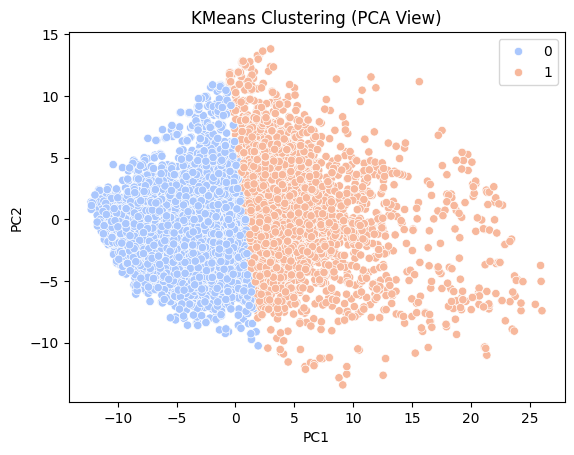

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

sns.scatterplot(x=pca_proj[:, 0], y=pca_proj[:, 1], hue=clusters, palette='coolwarm')
plt.title("KMeans Clustering (PCA View)")
plt.xlabel("PC1")
plt.ylabel("PC2")
<plt.show()

>KMeans clustering with two clusters shows a clean partition in PCA space, forming two dense and compact groups. While the clustering does not use the `Mutagenic` labels, the result aligns moderately with the data structure, indicating that unsupervised grouping captures meaningful variance in the descriptors. This suggests potential for separating mutagenic profiles based on chemical features alone, although overlap remains.



## 4.5 Hierarchical clustering (dendrogram)

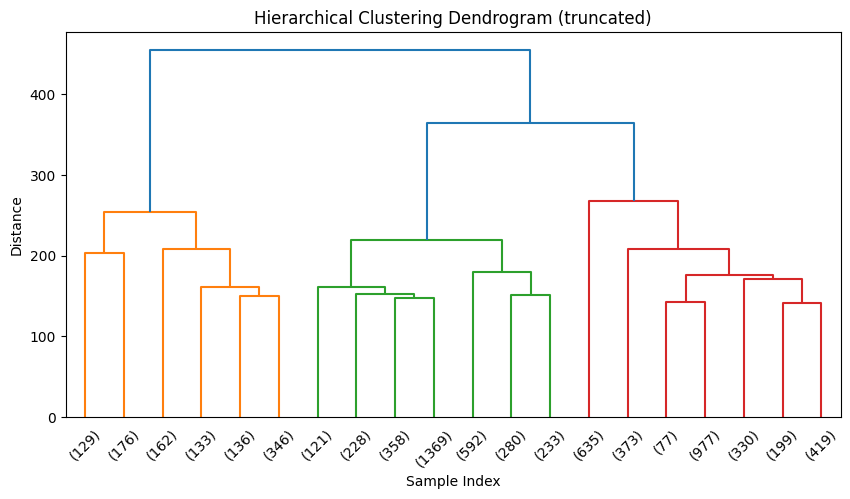

In [88]:
linkage_matrix = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, truncate_mode='lastp', p=20, leaf_rotation=45., leaf_font_size=10.)
plt.title("Hierarchical Clustering Dendrogram (truncated)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

>The dendrogram reveals a hierarchical grouping of samples based on molecular descriptor similarity. Clear substructures emerge at various distances, indicating regions of higher local similarity in the descriptor space. However, since the clustering is unsupervised and the leaves are not annotated by `Mutagenic`, no biological interpretation can be made without further label-based analysis. The truncation provides a compact overview of representative sample clusters, suitable for initial exploration of chemical diversity.



### **Conclusion of Unsupervised Analysis**

Dimensionality reduction (PCA, t-SNE) and clustering (KMeans, hierarchical) allowed the visualization and grouping of structurally similar compounds. While some separability and local patterns emerged, unsupervised methods alone did not reveal a clear distinction between mutagenic and non-mutagenic compounds. This reinforces the need for supervised learning methods capable of modeling more complex, nonlinear relationships in the data.



Given the limited interpretability of class separation in the unsupervised setting, the next step is to apply supervised machine learning algorithms. These models will learn to predict mutagenicity from molecular descriptors using known labeled data, enabling evaluation of predictive power and variable importance.



# 5. Supervised ML

# 6. Variable selection/importance used by the models